# 08. Expansão e regularização: Ridge, Lasso e Elastic Net

## Objetivo

Aplicar **Ridge (L2)**, **Lasso (L1)** e **Elastic Net** à mesma especificação da regressão linear múltipla consolidada da etapa anterior.

A regressão original é:

$$
\text{Valor FOB} \sim \text{Volume} * \text{Rota Líder}
$$

A especificação é mantida. O objetivo desta etapa é investigar como a regularização modifica os coeficientes e o desempenho preditivo em validação cruzada.

A Aula 08 apresenta a regularização como um mecanismo de controle da complexidade do modelo: Ridge encolhe os coeficientes, Lasso também pode zerá-los e Elastic Net combina as duas penalizações.

## 0. Configurações e carregamento da base

A estrutura atual do projeto mantém os arquivos dentro da pasta `estrutura/`.

A base utilizada é `estrutura/data/processed/df_sazonal_lideres.csv`.

A preparação abaixo reproduz a mesma construção usada na regressão múltipla original: volume em milhões de toneladas, Valor FOB em milhões de US$ e um fator `rota_lider` que identifica cada combinação de município, fluxo, país e produto.

In [2]:
# Pacotes
pacotes <- c(
  "readr",
  "dplyr",
  "stringr",
  "ggplot2",
  "scales",
  "glmnet",
  "tibble"
)

instalar <- pacotes[!(pacotes %in% rownames(installed.packages()))]

if (length(instalar) > 0) {
  install.packages(instalar, repos = "https://cloud.r-project.org")
}

invisible(lapply(pacotes, library, character.only = TRUE))
options(scipen = 999, digits = 4)

# Localiza a pasta estrutura/
caminho_atual <- normalizePath(getwd(), winslash = "/", mustWork = FALSE)

if (basename(caminho_atual) == "R" && basename(dirname(caminho_atual)) == "estrutura") {
  raiz_estrutura <- dirname(caminho_atual)
} else if (basename(caminho_atual) == "notebooks" && basename(dirname(caminho_atual)) == "estrutura") {
  raiz_estrutura <- dirname(caminho_atual)
} else if (basename(caminho_atual) == "estrutura") {
  raiz_estrutura <- caminho_atual
} else if (basename(caminho_atual) == "notebooks") {
  raiz_estrutura <- dirname(caminho_atual)
} else {
  candidato <- file.path(caminho_atual, "estrutura")
  raiz_estrutura <- if (dir.exists(candidato)) candidato else caminho_atual
}

caminho_csv <- file.path(
  raiz_estrutura, "data", "processed", "df_sazonal_lideres.csv"
)

if (!file.exists(caminho_csv)) {
  stop("Base não encontrada em: ", caminho_csv)
}

df_sazonal_lideres <- read_csv2(caminho_csv, show_col_types = FALSE)

cat(sprintf(
  "Base carregada: %d observações mensais.\n",
  nrow(df_sazonal_lideres)
))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



also installing the dependencies ‘iterators’, ‘foreach’, ‘shape’, ‘RcppEigen’


Loading required package: Matrix

Loaded glmnet 5.0

ℹ Using "','" as decimal and "'.'" as grouping mark. Use `read_delim()` for more control.



Base carregada: 481 observações mensais.


## 1. Preparação dos dados

A regressão múltipla original utiliza:

- `volume_mil_ton = Quilograma Líquido / 1e6`;
- `valor_milhoes_fob = Valor US$ FOB / 1e6`;
- `rota_lider` como fator identificador da combinação Município + Fluxo + País + Descrição SH4.

Nenhum novo preditor é acrescentado nesta etapa. Assim, a regularização é aplicada exatamente à estrutura da regressão múltipla anterior.

In [3]:
df_multipla <- df_sazonal_lideres |>
  mutate(
    volume_mil_ton = `Quilograma Líquido` / 1e6,
    valor_milhoes_fob = `Valor US$ FOB` / 1e6,
    rota_lider = factor(
      paste(
        Município, Fluxo, País,
        str_trunc(`Descrição SH4`, 15),
        sep = " | "
      )
    )
  )

formula_multipla <- valor_milhoes_fob ~ volume_mil_ton * rota_lider

rotas <- levels(df_multipla$rota_lider)
rotas

[1] "Cubatão - SP | Exportação | China | Soja, mesmo ..."         
[2] "Cubatão - SP | Importação | Chile | Sal (incluíd..."         
[3] "Guarujá - SP | Exportação | China | Soja, mesmo ..."         
[4] "Guarujá - SP | Importação | Estados Unidos | Hidróxido de..."
[5] "Santos - SP | Exportação | China | Soja, mesmo ..."          
[6] "Santos - SP | Importação | Argentina | Trigo e mist..."

## 2. Matriz de preditores

Para o `glmnet`, a fórmula é transformada em uma matriz numérica por `model.matrix()`.

O intercepto é retirado da matriz `X`, pois o `glmnet` estima seu próprio intercepto. A matriz mantém:

1. o volume;
2. as variáveis indicadoras das rotas;
3. as interações entre volume e rota.

Essa é a mesma estrutura de preditores produzida pela regressão OLS com `volume_mil_ton * rota_lider`.

In [4]:
X <- model.matrix(
  formula_multipla,
  data = df_multipla
)[, -1, drop = FALSE]

y <- df_multipla$valor_milhoes_fob

cat("Dimensões de X:", nrow(X), "observações x", ncol(X), "preditores\n")
colnames(X)

if (anyNA(X) || anyNA(y)) {
  stop("Existem valores ausentes em X ou y.")
}

Dimensões de X: 481 observações x 11 preditores


[1] "volume_mil_ton"                                                                       
 [2] "rota_liderCubatão - SP | Importação | Chile | Sal (incluíd..."                        
 [3] "rota_liderGuarujá - SP | Exportação | China | Soja, mesmo ..."                        
 [4] "rota_liderGuarujá - SP | Importação | Estados Unidos | Hidróxido de..."               
 [5] "rota_liderSantos - SP | Exportação | China | Soja, mesmo ..."                         
 [6] "rota_liderSantos - SP | Importação | Argentina | Trigo e mist..."                     
 [7] "volume_mil_ton:rota_liderCubatão - SP | Importação | Chile | Sal (incluíd..."         
 [8] "volume_mil_ton:rota_liderGuarujá - SP | Exportação | China | Soja, mesmo ..."         
 [9] "volume_mil_ton:rota_liderGuarujá - SP | Importação | Estados Unidos | Hidróxido de..."
[10] "volume_mil_ton:rota_liderSantos - SP | Exportação | China | Soja, mesmo ..."          
[11] "volume_mil_ton:rota_liderSantos - SP | Importação | Argentina | Trigo e mist..."

## 3. OLS como modelo de referência

A OLS não é substituída. Ela funciona aqui como **baseline** para a comparação com os modelos regularizados.

O desempenho preditivo será comparado por validação cruzada, e não pelo R² de treinamento.

In [5]:
modelo_ols <- lm(formula_multipla, data = df_multipla)
resumo_ols <- summary(modelo_ols)

rmse_ols_treino <- sqrt(mean(residuals(modelo_ols)^2))
r2_ols <- resumo_ols$r.squared
r2_aj_ols <- resumo_ols$adj.r.squared

tibble(
  R2 = r2_ols,
  R2_Ajustado = r2_aj_ols,
  RMSE_Treino = rmse_ols_treino
)

R2,R2_Ajustado,RMSE_Treino
<dbl>,<dbl>,<dbl>
0.9451,0.9438,11.95


## 4. Validação cruzada

A Aula 08 utiliza validação cruzada para escolher o valor de `lambda`.

Serão usados 10 folds, com a **mesma divisão dos dados para todos os modelos**. Isso permite comparar OLS, Ridge, Lasso e Elastic Net em condições de validação semelhantes.

Para o OLS, o RMSE é calculado manualmente nos mesmos folds. Para os modelos `glmnet`, a validação cruzada é realizada por `cv.glmnet()`.

In [6]:
set.seed(1)

K <- 10
foldid <- sample(rep(seq_len(K), length.out = nrow(X)))

rmse_ols_cv <- function(X, y, foldid) {
  erros <- numeric(max(foldid))

  for (k in sort(unique(foldid))) {
    treino <- foldid != k
    teste <- foldid == k

    modelo_cv <- lm.fit(
      x = cbind(`(Intercept)` = 1, X[treino, , drop = FALSE]),
      y = y[treino]
    )

    X_teste <- cbind(`(Intercept)` = 1, X[teste, , drop = FALSE])
    pred <- as.vector(X_teste %*% coef(modelo_cv))

    erros[k] <- mean((y[teste] - pred)^2)
  }

  sqrt(mean(erros))
}

rmse_ols_cv_val <- rmse_ols_cv(X, y, foldid)
rmse_ols_cv_val

[1] 12.51

## 5. Ridge — penalização L2

Na Ridge, a função objetivo acrescenta uma penalização proporcional à soma dos quadrados dos coeficientes.

A Aula 08 destaca que:

- `lambda = 0` se aproxima da OLS;
- o aumento de `lambda` encolhe os coeficientes;
- o intercepto não é penalizado;
- `lambda` é escolhido por validação cruzada;
- o `glmnet` padroniza os preditores por padrão.

Aqui usamos `alpha = 0`.

In [7]:
set.seed(1)

cv_ridge <- cv.glmnet(
  X, y,
  alpha = 0,
  nfolds = K,
  foldid = foldid,
  standardize = TRUE,
  type.measure = "mse"
)

lambda_ridge <- cv_ridge$lambda.min
mse_ridge_cv <- min(cv_ridge$cvm)
rmse_ridge_cv <- sqrt(mse_ridge_cv)

coef_ridge <- coef(cv_ridge, s = "lambda.min")
coef_ridge_df <- tibble(
  Termo = rownames(as.matrix(coef_ridge)),
  Coeficiente = as.numeric(coef_ridge)
)

n_ridge <- sum(abs(coef_ridge_df$Coeficiente[-1]) > 1e-10)

tibble(
  Lambda = lambda_ridge,
  CV_MSE = mse_ridge_cv,
  CV_RMSE = rmse_ridge_cv,
  Preditores_Nao_Nulos = n_ridge
)

Lambda,CV_MSE,CV_RMSE,Preditores_Nao_Nulos
<dbl>,<dbl>,<dbl>,<int>
4.882,175.1,13.23,11


## 6. Lasso — penalização L1

Na Lasso, a penalização é proporcional à soma dos valores absolutos dos coeficientes.

A diferença importante em relação à Ridge é que a Lasso pode levar alguns coeficientes exatamente a zero. Por isso, além da redução de magnitude, ela pode produzir uma seleção de termos.

Serão examinados os dois critérios apresentados na Aula 08:

- `lambda.min`: menor erro médio de validação cruzada;
- `lambda.1se`: regra de 1 erro-padrão, favorecendo uma solução mais simples.

In [8]:
set.seed(1)

cv_lasso <- cv.glmnet(
  X, y,
  alpha = 1,
  nfolds = K,
  foldid = foldid,
  standardize = TRUE,
  type.measure = "mse"
)

lambda_lasso_min <- cv_lasso$lambda.min
lambda_lasso_1se <- cv_lasso$lambda.1se

idx_min <- which.min(abs(cv_lasso$lambda - lambda_lasso_min))
idx_1se <- which.min(abs(cv_lasso$lambda - lambda_lasso_1se))

rmse_lasso_min <- sqrt(cv_lasso$cvm[idx_min])
rmse_lasso_1se <- sqrt(cv_lasso$cvm[idx_1se])

coef_lasso_min <- coef(cv_lasso, s = "lambda.min")
coef_lasso_1se <- coef(cv_lasso, s = "lambda.1se")

coef_lasso_1se_df <- tibble(
  Termo = rownames(as.matrix(coef_lasso_1se)),
  Coeficiente = as.numeric(coef_lasso_1se)
)

n_lasso_min <- sum(abs(as.numeric(coef_lasso_min)[-1]) > 1e-10)
n_lasso_1se <- sum(abs(coef_lasso_1se_df$Coeficiente[-1]) > 1e-10)

tibble(
  Criterio = c("lambda.min", "lambda.1se"),
  Lambda = c(lambda_lasso_min, lambda_lasso_1se),
  CV_RMSE = c(rmse_lasso_min, rmse_lasso_1se),
  Preditores_Nao_Nulos = c(n_lasso_min, n_lasso_1se)
)

Criterio,Lambda,CV_RMSE,Preditores_Nao_Nulos
<chr>,<dbl>,<dbl>,<int>
lambda.min,0.2667,12.41,7
lambda.1se,2.4868,13.38,5


In [9]:
# Termos mantidos pela Lasso em lambda.1se
coef_lasso_1se_df |>
  filter(Termo != "(Intercept)", abs(Coeficiente) > 1e-10)

# Termos zerados pela Lasso em lambda.1se
coef_lasso_1se_df |>
  filter(Termo != "(Intercept)", abs(Coeficiente) <= 1e-10) |>
  select(Termo)

Termo,Coeficiente
<chr>,<dbl>
volume_mil_ton,0.429853
"rota_liderSantos - SP | Exportação | China | Soja, mesmo ...",0.000650
volume_mil_ton:rota_liderCubatão - SP | Importação | Chile | Sal (incluíd...,-0.257376
volume_mil_ton:rota_liderGuarujá - SP | Importação | Estados Unidos | Hidróxido de...,-0.004006
volume_mil_ton:rota_liderSantos - SP | Importação | Argentina | Trigo e mist...,-0.017070


Termo
<chr>
rota_liderCubatão - SP | Importação | Chile | Sal (incluíd...
"rota_liderGuarujá - SP | Exportação | China | Soja, mesmo ..."
rota_liderGuarujá - SP | Importação | Estados Unidos | Hidróxido de...
rota_liderSantos - SP | Importação | Argentina | Trigo e mist...
"volume_mil_ton:rota_liderGuarujá - SP | Exportação | China | Soja, mesmo ..."
"volume_mil_ton:rota_liderSantos - SP | Exportação | China | Soja, mesmo ..."


## 7. Elastic Net

O Elastic Net combina as penalizações L1 e L2.

Na parametrização do `glmnet`:

- `alpha = 0` corresponde à Ridge;
- `alpha = 1` corresponde à Lasso;
- valores intermediários combinam as duas.

Seguindo a aplicação prática apresentada na Aula 08, será usado inicialmente `alpha = 0.5`, sem transformar esta etapa em uma busca adicional de `alpha`.

In [10]:
set.seed(1)

alpha_enet <- 0.5

cv_enet <- cv.glmnet(
  X, y,
  alpha = alpha_enet,
  nfolds = K,
  foldid = foldid,
  standardize = TRUE,
  type.measure = "mse"
)

lambda_enet <- cv_enet$lambda.min
mse_enet_cv <- min(cv_enet$cvm)
rmse_enet_cv <- sqrt(mse_enet_cv)

coef_enet <- coef(cv_enet, s = "lambda.min")
coef_enet_df <- tibble(
  Termo = rownames(as.matrix(coef_enet)),
  Coeficiente = as.numeric(coef_enet)
)

n_enet <- sum(abs(coef_enet_df$Coeficiente[-1]) > 1e-10)

tibble(
  Alpha = alpha_enet,
  Lambda = lambda_enet,
  CV_MSE = mse_enet_cv,
  CV_RMSE = rmse_enet_cv,
  Preditores_Nao_Nulos = n_enet
)

Alpha,Lambda,CV_MSE,CV_RMSE,Preditores_Nao_Nulos
<dbl>,<dbl>,<dbl>,<dbl>,<int>
0.5,0.2103,155.5,12.47,9


## 8. Comparação preditiva

A comparação principal será feita pelo erro de validação cruzada.

O objetivo não é escolher um modelo apenas porque possui maior R² de treinamento. A regularização introduz viés deliberadamente para controlar a complexidade e pode melhorar a capacidade preditiva fora da amostra.

In [11]:
comparacao_modelos <- tibble(
  Modelo = c("OLS", "Ridge", "Lasso", "Lasso", "Elastic Net"),
  Alpha = c(NA, 0, 1, 1, alpha_enet),
  Lambda = c(
    NA,
    lambda_ridge,
    lambda_lasso_min,
    lambda_lasso_1se,
    lambda_enet
  ),
  Selecao_Lambda = c(
    "OLS",
    "lambda.min",
    "lambda.min",
    "lambda.1se",
    "lambda.min"
  ),
  CV_MSE = c(
    rmse_ols_cv_val^2,
    mse_ridge_cv,
    rmse_lasso_min^2,
    rmse_lasso_1se^2,
    mse_enet_cv
  ),
  CV_RMSE = c(
    rmse_ols_cv_val,
    rmse_ridge_cv,
    rmse_lasso_min,
    rmse_lasso_1se,
    rmse_enet_cv
  ),
  Preditores_Nao_Nulos = c(
    ncol(X),
    n_ridge,
    n_lasso_min,
    n_lasso_1se,
    n_enet
  )
)

comparacao_modelos

Modelo,Alpha,Lambda,Selecao_Lambda,CV_MSE,CV_RMSE,Preditores_Nao_Nulos
<chr>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<int>
OLS,NA,NA,OLS,156.6,12.51,11
Ridge,0.0,4.8818,lambda.min,175.1,13.23,11
Lasso,1.0,0.2667,lambda.min,154.0,12.41,7
Lasso,1.0,2.4868,lambda.1se,179.0,13.38,5
Elastic Net,0.5,0.2103,lambda.min,155.5,12.47,9


## 9. Comparação dos coeficientes

A tabela abaixo permite observar diretamente o efeito da regularização sobre os termos da mesma regressão.

A Lasso é apresentada com `lambda.1se`, pois esse é o ponto em que a Aula 08 enfatiza a obtenção de uma solução mais simples.

In [12]:
coef_ols <- coef(modelo_ols)

coef_ridge_v <- as.numeric(coef_ridge)
names(coef_ridge_v) <- rownames(as.matrix(coef_ridge))

coef_lasso_v <- as.numeric(coef_lasso_1se)
names(coef_lasso_v) <- rownames(as.matrix(coef_lasso_1se))

coef_enet_v <- as.numeric(coef_enet)
names(coef_enet_v) <- rownames(as.matrix(coef_enet))

todos_termos <- unique(c(
  names(coef_ols),
  names(coef_ridge_v),
  names(coef_lasso_v),
  names(coef_enet_v)
))

comparacao_coeficientes <- tibble(
  Termo = todos_termos,
  OLS = unname(coef_ols[Termo]),
  Ridge = unname(coef_ridge_v[Termo]),
  Lasso_lambda_1se = unname(coef_lasso_v[Termo]),
  Elastic_Net = unname(coef_enet_v[Termo])
)

comparacao_coeficientes

Termo,OLS,Ridge,Lasso_lambda_1se,Elastic_Net
<chr>,<dbl>,<dbl>,<dbl>,<dbl>
(Intercept),-0.71827,7.44306,-2.644075,0.459309
volume_mil_ton,0.47291,0.25570,0.429853,0.437940
rota_liderCubatão - SP | Importação | Chile | Sal (incluíd...,0.89105,-8.89619,0.000000,-0.723404
"rota_liderGuarujá - SP | Exportação | China | Soja, mesmo ...",0.71326,-2.19361,0.000000,0.000000
rota_liderGuarujá - SP | Importação | Estados Unidos | Hidróxido de...,0.59110,-6.46197,0.000000,-0.541273
"rota_liderSantos - SP | Exportação | China | Soja, mesmo ...",1.75001,-0.55992,0.000650,0.413492
rota_liderSantos - SP | Importação | Argentina | Trigo e mist...,1.18733,-5.02768,0.000000,-0.032098
volume_mil_ton:rota_liderCubatão - SP | Importação | Chile | Sal (incluíd...,-0.45309,-0.19261,-0.257376,-0.405555
"volume_mil_ton:rota_liderGuarujá - SP | Exportação | China | Soja, mesmo ...",-0.02715,0.15185,0.000000,0.004102


## 10. Curvas de validação cruzada

Os gráficos mostram o erro de validação cruzada em função de `lambda`. As linhas verticais indicam os valores utilizados pelo `cv.glmnet`, incluindo `lambda.min` e, no caso da Lasso, `lambda.1se`.

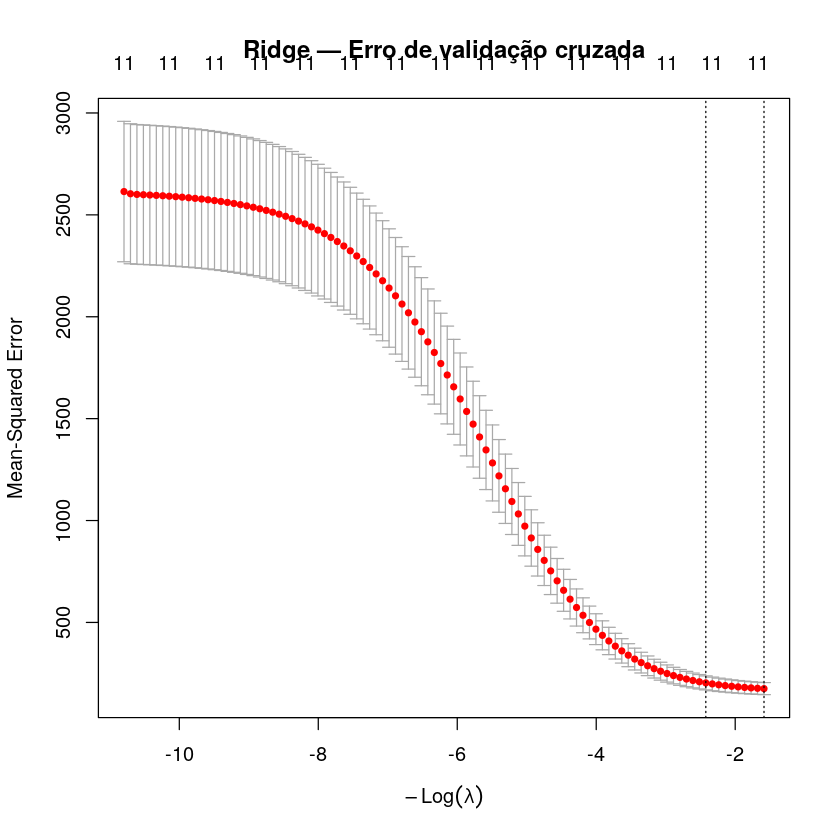

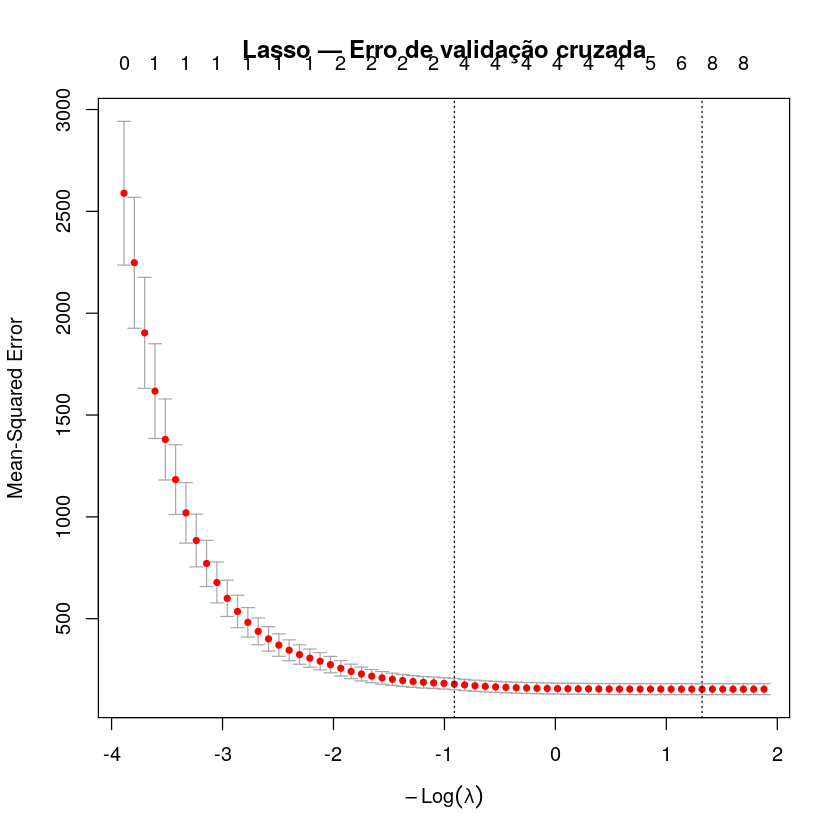

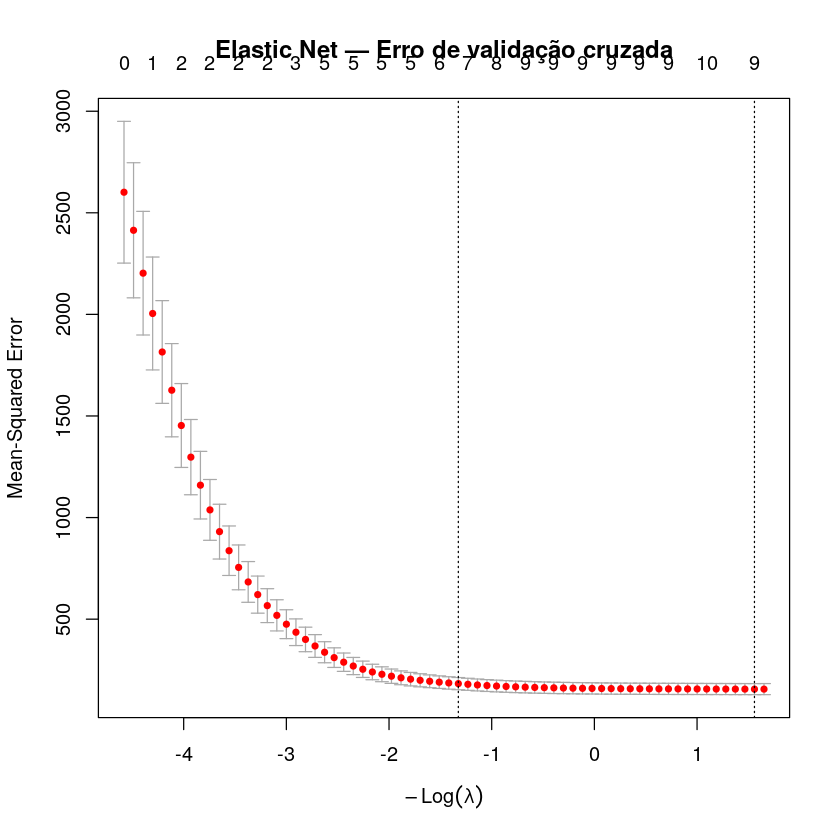

In [13]:
plot(cv_ridge, main = "Ridge — Erro de validação cruzada")
plot(cv_lasso, main = "Lasso — Erro de validação cruzada")
plot(cv_enet, main = "Elastic Net — Erro de validação cruzada")

## 11. Caminhos dos coeficientes

Os caminhos dos coeficientes ajudam a visualizar a diferença entre as penalizações.

Na Ridge, os coeficientes são progressivamente encolhidos.

Na Lasso, alguns termos podem ser levados exatamente a zero, produzindo seleção de preditores.

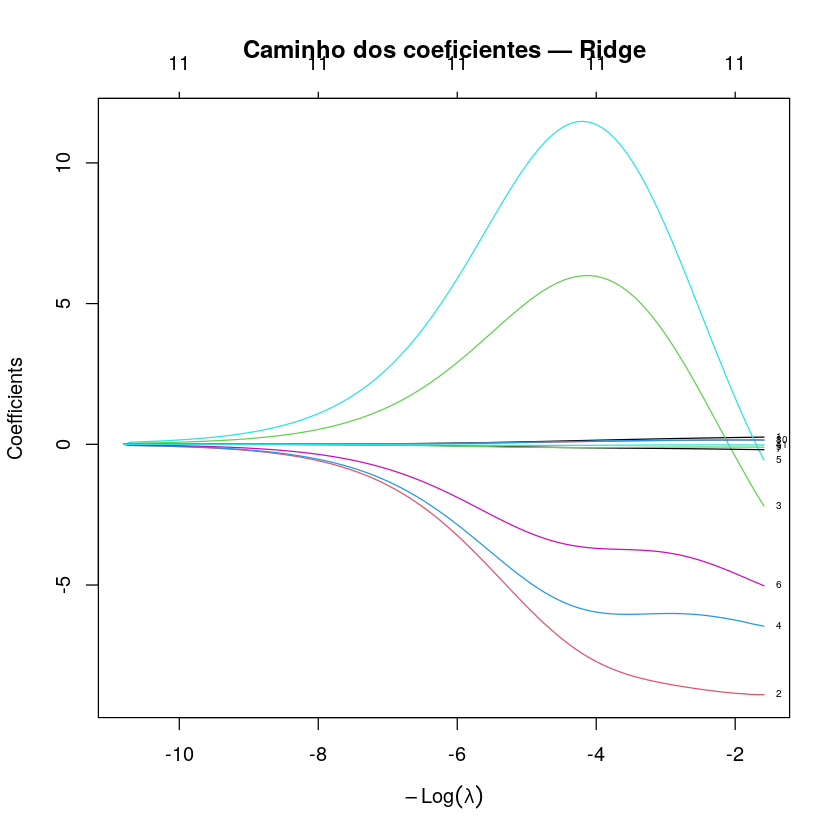

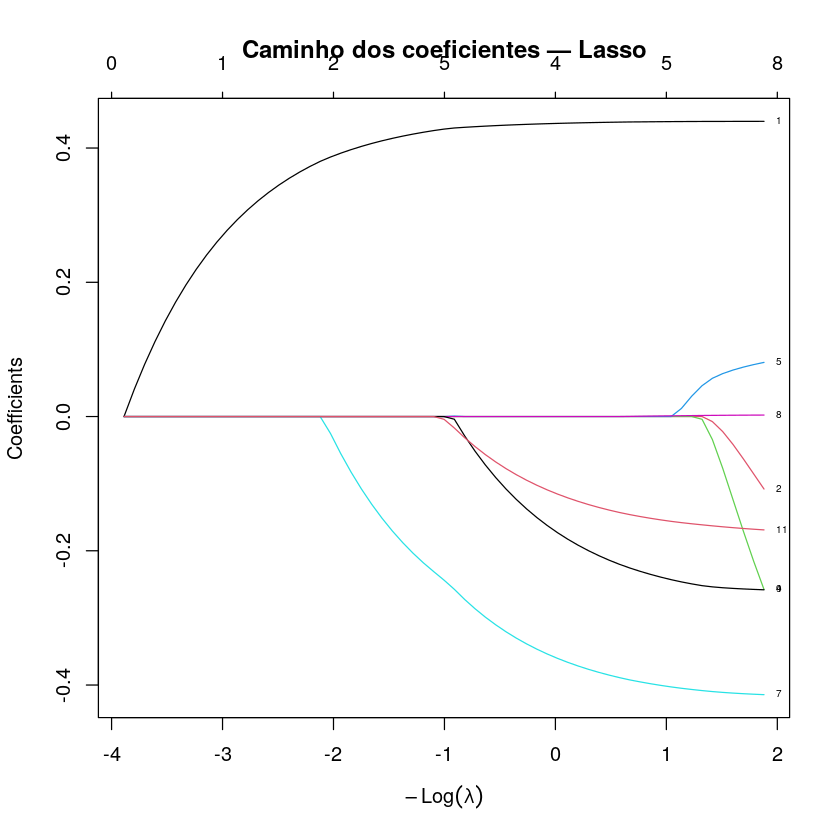

In [14]:
plot(
  cv_ridge$glmnet.fit,
  xvar = "lambda",
  label = TRUE,
  main = "Caminho dos coeficientes — Ridge"
)

plot(
  cv_lasso$glmnet.fit,
  xvar = "lambda",
  label = TRUE,
  main = "Caminho dos coeficientes — Lasso"
)

## 12. Conclusão da etapa

A análise deve ser concluída a partir dos valores efetivamente produzidos pelo código.

Pontos que devem ser observados:

- qual `lambda.min` foi selecionado para Ridge;
- qual `lambda.min` e qual `lambda.1se` foram selecionados para Lasso;
- quantos termos permaneceram não nulos em cada solução;
- como os coeficientes foram encolhidos em relação à OLS;
- qual foi o RMSE de validação cruzada de cada modelo;
- se o Elastic Net, com `alpha = 0.5`, apresentou comportamento intermediário entre Ridge e Lasso.

Um termo zerado pelo Lasso representa uma seleção dentro do modelo regularizado. Isso não deve ser interpretado como prova de ausência de relação causal.